## 0. Cài đặt môi trường

Nếu chạy trên Google Colab hoặc máy chưa có PySpark, mở comment dòng `%pip install -q pyspark`.

Nếu chạy trên Databricks, EMR, HDInsight hoặc Spark cluster đã có sẵn Spark thì bỏ qua bước cài đặt.

In [ ]:
# Nếu môi trường chưa có PySpark, mở comment dòng dưới:
# %pip install -q pyspark

## 1. Khởi tạo SparkSession

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

spark = (
    SparkSession.builder
    .appName("DiabetesReadmissionPrediction_Spark")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 4.1.1


## 2. Nạp dữ liệu

Notebook ưu tiên đọc file `diabetic_data.csv` từ thư mục làm việc hiện tại.

Nếu chưa có file, có thể dùng cell tải dữ liệu từ UCI bên dưới. Sau khi tải và giải nén, Spark sẽ đọc trực tiếp file CSV 


In [ ]:
import os
import urllib.request
import zipfile

DATA_PATH = "diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv"
UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/296/diabetes%2B130-us%2Bhospitals%2Bfor%2Byears%2B1999-2008.zip"
ZIP_PATH = "diabetes+130-us+hospitals+for+years+1999-2008.zip"

if not os.path.exists(DATA_PATH):
    print(f"Không tìm thấy {DATA_PATH}. Đang thử tải dữ liệu từ UCI...")
    urllib.request.urlretrieve(UCI_ZIP_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(".")
    print("Đã tải và giải nén dữ liệu.")
else:
    print(f"Đã tìm thấy {DATA_PATH}.")

Đã tìm thấy diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv.


<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\anh.nd6\AppData\Local\Temp\ipykernel_15916\3029494199.py:5: SyntaxWarning: invalid escape sequence '\d'
  DATA_PATH = "diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv"


In [4]:
df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

df_raw.cache()

print("Số dòng:", df_raw.count())
print("Số cột:", len(df_raw.columns))
df_raw.printSchema()

Số dòng: 101766
Số cột: 50
root
 |-- encounter_id: integer (nullable = true)
 |-- patient_nbr: integer (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: string (nullable = true)
 |-- weight: string (nullable = true)
 |-- admission_type_id: integer (nullable = true)
 |-- discharge_disposition_id: integer (nullable = true)
 |-- admission_source_id: integer (nullable = true)
 |-- time_in_hospital: integer (nullable = true)
 |-- payer_code: string (nullable = true)
 |-- medical_specialty: string (nullable = true)
 |-- num_lab_procedures: integer (nullable = true)
 |-- num_procedures: integer (nullable = true)
 |-- num_medications: integer (nullable = true)
 |-- number_outpatient: integer (nullable = true)
 |-- number_emergency: integer (nullable = true)
 |-- number_inpatient: integer (nullable = true)
 |-- diag_1: string (nullable = true)
 |-- diag_2: string (nullable = true)
 |-- diag_3: string (nullable = true)
 |-- number_diagnoses: in

In [5]:
df_raw.show(5, truncate=False)

+------------+-----------+---------------+------+-------+------+-----------------+------------------------+-------------------+----------------+----------+------------------------+------------------+--------------+---------------+-----------------+----------------+----------------+------+------+------+----------------+-------------+---------+---------+-----------+-----------+--------------+-----------+-------------+---------+---------+-----------+------------+-------------+--------+--------+------------+----------+-------+-----------+-------+-------------------+-------------------+------------------------+-----------------------+----------------------+------+-----------+----------+
|encounter_id|patient_nbr|race           |gender|age    |weight|admission_type_id|discharge_disposition_id|admission_source_id|time_in_hospital|payer_code|medical_specialty       |num_lab_procedures|num_procedures|num_medications|number_outpatient|number_emergency|number_inpatient|diag_1|diag_2|diag_3|number

## 3. Khám phá dữ liệu bằng Spark DataFrame và Spark SQL

Các thao tác thống kê tổng quan được thực hiện bằng Spark thay vì pandas.

In [6]:
# Phân phối nhãn gốc readmitted
df_raw.groupBy("readmitted").count().orderBy(F.desc("count")).show()

+----------+-----+
|readmitted|count|
+----------+-----+
|        NO|54864|
|       >30|35545|
|       <30|11357|
+----------+-----+



In [7]:
# Thống kê một số biến số quan trọng
numeric_preview_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

df_raw.select(numeric_preview_cols).describe().show(truncate=False)

+-------+------------------+------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+
|summary|time_in_hospital  |num_lab_procedures|num_procedures    |num_medications   |number_outpatient  |number_emergency   |number_inpatient  |number_diagnoses  |
+-------+------------------+------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+
|count  |101766            |101766            |101766            |101766            |101766             |101766             |101766            |101766            |
|mean   |4.395986871843248 |43.09564098028811 |1.339730361810428 |16.021844230882614|0.36935715268360747|0.19783621248747127|0.635565906098304 |7.422606764538254 |
|stddev |2.9851077674712645|19.67436224914214 |1.7058069791211583|8.127566209167293 |1.2672650965326786 |0.9304722684224644 |1.2628632900973231|1.9336001449974298|
|min    |1      

In [8]:
# Sử dụng Spark SQL để kiểm tra một số thống kê theo nhóm tuổi
df_raw.createOrReplaceTempView("diabetes_raw")

spark.sql('''
SELECT age, readmitted, COUNT(*) AS n
FROM diabetes_raw
GROUP BY age, readmitted
ORDER BY age, readmitted
''').show(50, truncate=False)

+--------+----------+-----+
|age     |readmitted|n    |
+--------+----------+-----+
|[0-10)  |<30       |3    |
|[0-10)  |>30       |26   |
|[0-10)  |NO        |132  |
|[10-20) |<30       |40   |
|[10-20) |>30       |224  |
|[10-20) |NO        |427  |
|[20-30) |<30       |236  |
|[20-30) |>30       |510  |
|[20-30) |NO        |911  |
|[30-40) |<30       |424  |
|[30-40) |>30       |1187 |
|[30-40) |NO        |2164 |
|[40-50) |<30       |1027 |
|[40-50) |>30       |3278 |
|[40-50) |NO        |5380 |
|[50-60) |<30       |1668 |
|[50-60) |>30       |5917 |
|[50-60) |NO        |9671 |
|[60-70) |<30       |2502 |
|[60-70) |>30       |7897 |
|[60-70) |NO        |12084|
|[70-80) |<30       |3069 |
|[70-80) |>30       |9475 |
|[70-80) |NO        |13524|
|[80-90) |<30       |2078 |
|[80-90) |>30       |6223 |
|[80-90) |NO        |8896 |
|[90-100)|<30       |310  |
|[90-100)|>30       |808  |
|[90-100)|NO        |1675 |
+--------+----------+-----+



## 4. Làm sạch dữ liệu

Các bước chính:

1. Thay ký hiệu thiếu `?` bằng `NULL`.
2. Loại bỏ các trường hợp xuất viện liên quan đến tử vong hoặc hospice.
3. Loại bỏ giới tính `Unknown/Invalid`.
4. Tạo biến mục tiêu nhị phân `label`:
   - `1`: tái nhập viện trong vòng 30 ngày (`readmitted = '<30'`)
   - `0`: không tái nhập viện trong vòng 30 ngày (`readmitted = '>30'` hoặc `NO`)

In [11]:
# Thay toàn bộ dấu '?' bằng NULL
df = df_raw.replace("?", None)

# Loại bỏ các trường hợp discharge_disposition_id liên quan đến tử vong/hospice
death_or_hospice_ids = [11, 13, 14, 19, 20, 21]

df = (
    df
    .filter(~F.col("discharge_disposition_id").isin(death_or_hospice_ids))
    .filter(F.col("gender") != "Unknown/Invalid")
    .withColumn("label", F.when(F.col("readmitted") == "<30", F.lit(1.0)).otherwise(F.lit(0.0)))
)

df.cache()

print("Số dòng sau làm sạch:", df.count())
df.groupBy("label").count().orderBy("label").show()

Số dòng sau làm sạch: 99340
+-----+-----+
|label|count|
+-----+-----+
|  0.0|88026|
|  1.0|11314|
+-----+-----+



In [12]:
# Hàm tính prevalence của lớp dương
def calc_prevalence_spark(dataframe, label_col="label"):
    total = dataframe.count()
    positive = dataframe.filter(F.col(label_col) == 1.0).count()
    return positive / total if total else 0.0

print("Prevalence tái nhập viện <30 ngày:", round(calc_prevalence_spark(df), 4))

Prevalence tái nhập viện <30 ngày: 0.1139


## 5. Feature Engineering bằng Spark

Notebook sử dụng các nhóm đặc trưng:

- Biến số: số ngày nằm viện, số xét nghiệm, số thủ thuật, số thuốc, số lần khám ngoại trú/cấp cứu/nội trú trước đó, số chẩn đoán.
- Biến phân loại: chủng tộc, giới tính, nhóm tuổi, nguồn nhập viện, loại nhập viện, hình thức xuất viện, kết quả xét nghiệm, thuốc.
- Biến bổ sung:
  - `age_group`: ánh xạ nhóm tuổi thành số thứ tự.
  - `has_weight`: bệnh nhân có thông tin cân nặng hay không.
  - `medical_specialty_clean`: gom các chuyên khoa ít gặp vào nhóm `Other`.

In [13]:
# Các biến số dùng trực tiếp
cols_num = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

# Ép kiểu double cho biến số
for c in cols_num:
    df = df.withColumn(c, F.col(c).cast("double"))

# Tạo age_group dạng số thứ tự
age_mapping = {
    "[0-10)": 0.0,
    "[10-20)": 1.0,
    "[20-30)": 2.0,
    "[30-40)": 3.0,
    "[40-50)": 4.0,
    "[50-60)": 5.0,
    "[60-70)": 6.0,
    "[70-80)": 7.0,
    "[80-90)": 8.0,
    "[90-100)": 9.0
}

mapping_expr = F.create_map([F.lit(x) for kv in age_mapping.items() for x in kv])

df = (
    df
    .withColumn("age_group", mapping_expr[F.col("age")].cast("double"))
    .withColumn("has_weight", F.when(F.col("weight").isNull(), F.lit(0.0)).otherwise(F.lit(1.0)))
)

cols_extra = ["age_group", "has_weight"]

In [14]:
# Gom medical_specialty: giữ top 10 nhóm phổ biến nhất, còn lại đưa vào Other
top_med_specs = [
    row["medical_specialty"]
    for row in (
        df.fillna({"medical_specialty": "UNK"})
          .groupBy("medical_specialty")
          .count()
          .orderBy(F.desc("count"))
          .limit(10)
          .collect()
    )
]

df = (
    df
    .withColumn(
        "medical_specialty_clean",
        F.when(F.col("medical_specialty").isin(top_med_specs), F.col("medical_specialty"))
         .otherwise(F.lit("Other"))
    )
)

df.groupBy("medical_specialty_clean").count().orderBy(F.desc("count")).show(20, truncate=False)

+--------------------------+-----+
|medical_specialty_clean   |count|
+--------------------------+-----+
|Other                     |56813|
|InternalMedicine          |14237|
|Emergency/Trauma          |7419 |
|Family/GeneralPractice    |7252 |
|Cardiology                |5278 |
|Surgery-General           |3059 |
|Nephrology                |1539 |
|Orthopedics               |1392 |
|Orthopedics-Reconstructive|1230 |
|Radiologist               |1121 |
+--------------------------+-----+



In [15]:
# Các biến phân loại dạng chuỗi
cols_cat = [
    "race",
    "gender",
    "payer_code",
    "medical_specialty_clean",
    "max_glu_serum",
    "A1Cresult",
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
    "change",
    "diabetesMed",
    "diag_1",
    "diag_2",
    "diag_3"
]

# Các biến id nhưng bản chất là categorical
cols_cat_num = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]

for c in cols_cat_num:
    df = df.withColumn(f"{c}_cat", F.col(c).cast("string"))

cols_cat_all = cols_cat + [f"{c}_cat" for c in cols_cat_num]

# Điền giá trị thiếu cho biến phân loại
df = df.fillna("UNK", subset=cols_cat_all)

# Điền giá trị thiếu cho age_group nếu có trường hợp bất thường
df = df.fillna({"age_group": -1.0})

print("Số biến số:", len(cols_num + cols_extra))
print("Số biến phân loại:", len(cols_cat_all))

Số biến số: 10
Số biến phân loại: 37


## 6. Chia train/validation/test

Chia dữ liệu theo tỷ lệ:

- Train: 70%
- Validation: 15%
- Test: 15%

Sử dụng `randomSplit` của Spark.

In [16]:
train_df, valid_df, test_df = df.randomSplit([0.70, 0.15, 0.15], seed=42)

train_df.cache()
valid_df.cache()
test_df.cache()

print("Train:", train_df.count(), "prevalence:", round(calc_prevalence_spark(train_df), 4))
print("Valid:", valid_df.count(), "prevalence:", round(calc_prevalence_spark(valid_df), 4))
print("Test :", test_df.count(), "prevalence:", round(calc_prevalence_spark(test_df), 4))

Train: 69762 prevalence: 0.1129
Valid: 14802 prevalence: 0.1153
Test : 14776 prevalence: 0.1172


## 7. Xử lý mất cân bằng lớp bằng `weightCol`

Vì lớp bệnh nhân tái nhập viện trong vòng 30 ngày thường chiếm tỷ lệ nhỏ, notebook tạo cột `class_weight` để mô hình chú ý nhiều hơn tới lớp dương.

In [17]:
total_train = train_df.count()
pos_train = train_df.filter(F.col("label") == 1.0).count()
neg_train = total_train - pos_train

pos_weight = total_train / (2.0 * pos_train) if pos_train > 0 else 1.0
neg_weight = total_train / (2.0 * neg_train) if neg_train > 0 else 1.0

def add_class_weight(dataframe):
    return dataframe.withColumn(
        "class_weight",
        F.when(F.col("label") == 1.0, F.lit(pos_weight)).otherwise(F.lit(neg_weight))
    )

train_df = add_class_weight(train_df)
valid_df = add_class_weight(valid_df)
test_df = add_class_weight(test_df)

print("Positive weight:", round(pos_weight, 4))
print("Negative weight:", round(neg_weight, 4))

train_df.groupBy("label", "class_weight").count().orderBy("label").show()

Positive weight: 4.4293
Negative weight: 0.5636
+-----+------------------+-----+
|label|      class_weight|count|
+-----+------------------+-----+
|  0.0|0.5636240244316254|61887|
|  1.0| 4.429333333333333| 7875|
+-----+------------------+-----+



## 8. Spark ML Pipeline cho tiền xử lý

Thay cho `pd.get_dummies` và `StandardScaler` của scikit-learn, notebook sử dụng:

- `StringIndexer`: chuyển category thành index.
- `OneHotEncoder`: one-hot encoding cho category.
- `VectorAssembler`: gom đặc trưng thành vector `features`.
- `StandardScaler`: chuẩn hóa vector đặc trưng.

In [19]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

# StringIndexer cho categorical columns
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in cols_cat_all
]

# OneHotEncoder cho indexed categorical columns
encoders = [
    OneHotEncoder(
        inputCols=[f"{c}_idx" for c in cols_cat_all],
        outputCols=[f"{c}_ohe" for c in cols_cat_all],
        handleInvalid="keep"
    )
]

feature_input_cols = cols_num + cols_extra + [f"{c}_ohe" for c in cols_cat_all]

assembler = VectorAssembler(
    inputCols=feature_input_cols,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)

preprocess_pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler])
preprocess_model = preprocess_pipeline.fit(train_df)

train_featurized = preprocess_model.transform(train_df).cache()
valid_featurized = preprocess_model.transform(valid_df).cache()
test_featurized = preprocess_model.transform(test_df).cache()

train_featurized.select("features", "label", "class_weight").show(5, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+------------------+
|features                                                                 

In [20]:
print("Số đặc trưng sau mã hóa:", train_featurized.select("features").first()["features"].size)

Số đặc trưng sau mã hóa: 2326


## 9. Huấn luyện mô hình bằng Spark MLlib

Các mô hình được chuyển từ scikit-learn sang Spark MLlib:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient-Boosted Tree Classifier

Lưu ý: KNN và Naive Bayes trong notebook gốc không được giữ làm mô hình chính vì không phù hợp bằng các mô hình Spark MLlib phía dưới cho dữ liệu bảng nhiều biến phân loại sau one-hot encoding.

In [21]:
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier
)

models = {
    "Logistic Regression": LogisticRegression(
        featuresCol="features",
        labelCol="label",
        weightCol="class_weight",
        maxIter=50,
        regParam=0.01,
        elasticNetParam=0.0
    ),
    "Decision Tree": DecisionTreeClassifier(
        featuresCol="features",
        labelCol="label",
        weightCol="class_weight",
        maxDepth=8,
        seed=42
    ),
    "Random Forest": RandomForestClassifier(
        featuresCol="features",
        labelCol="label",
        weightCol="class_weight",
        numTrees=100,
        maxDepth=8,
        featureSubsetStrategy="sqrt",
        seed=42
    ),
    "Gradient-Boosted Tree": GBTClassifier(
        featuresCol="features",
        labelCol="label",
        weightCol="class_weight",
        maxIter=50,
        maxDepth=5,
        seed=42
    )
}

## 10. Hàm đánh giá mô hình

Spark có `BinaryClassificationEvaluator` để tính ROC-AUC/PR-AUC. Các chỉ số Accuracy, Precision, Recall, F1-score được tính từ confusion matrix để tập trung vào lớp dương `label = 1`.

In [22]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql import DataFrame

auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

pr_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

def evaluate_binary_predictions(predictions: DataFrame, model_name: str, dataset_name: str):
    auc = auc_evaluator.evaluate(predictions)
    pr_auc = pr_evaluator.evaluate(predictions)

    cm = (
        predictions
        .select("label", "prediction")
        .groupBy("label", "prediction")
        .count()
        .collect()
    )

    counts = {(float(r["label"]), float(r["prediction"])): r["count"] for r in cm}
    tp = counts.get((1.0, 1.0), 0)
    tn = counts.get((0.0, 0.0), 0)
    fp = counts.get((0.0, 1.0), 0)
    fn = counts.get((1.0, 0.0), 0)

    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc,
        "pr_auc": pr_auc,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn
    }

## 11. So sánh các mô hình baseline

Các mô hình được huấn luyện trên `train_featurized`, đánh giá trên `train` và `validation`.

In [25]:
model_fits = {}
metrics = []

for model_name, estimator in models.items():
    print(f"Đang huấn luyện: {model_name}")

    fitted_model = estimator.fit(train_featurized)
    model_fits[model_name] = fitted_model

    train_pred = fitted_model.transform(train_featurized)
    valid_pred = fitted_model.transform(valid_featurized)

    train_metrics = evaluate_binary_predictions(
        train_pred,
        model_name,
        "train"
    )

    valid_metrics = evaluate_binary_predictions(
        valid_pred,
        model_name,
        "validation"
    )

    metrics.append(train_metrics)
    metrics.append(valid_metrics)

# Hiển thị kết quả bằng pandas thay vì Spark
import pandas as pd

metrics_pd = pd.DataFrame(metrics)

for col in metrics_pd.columns:
    if col not in ["model", "model_name", "dataset", "split"]:
        metrics_pd[col] = pd.to_numeric(metrics_pd[col], errors="coerce")

metrics_pd = metrics_pd.sort_values(
    by=["dataset", "roc_auc"],
    ascending=[True, False]
)

display(metrics_pd)

Đang huấn luyện: Logistic Regression
Đang huấn luyện: Decision Tree
Đang huấn luyện: Random Forest
Đang huấn luyện: Gradient-Boosted Tree


,model,dataset,accuracy,precision,recall,f1,roc_auc,pr_auc,tp,tn,fp,fn
0,Logistic Regression,train,0.672787,0.201724,0.642032,0.306992,0.728101,0.266144,5056,41879,20008,2819
6,Gradient-Boosted Tree,train,0.665577,0.200357,0.656127,0.306975,0.721599,0.271124,5167,41265,20622,2708
4,Random Forest,train,0.645638,0.185943,0.633270,0.287477,0.692023,0.227736,4987,40054,21833,2888
2,Decision Tree,train,0.670064,0.189127,0.584889,0.285830,0.506912,0.114863,4606,42139,19748,3269
7,Gradient-Boosted Tree,validation,0.648966,0.179614,0.572935,0.273490,0.660476,0.232344,978,8628,4467,729
5,Random Forest,validation,0.637279,0.175239,0.578793,0.269027,0.658988,0.198170,988,8445,4650,719
1,Logistic Regression,validation,0.655925,0.178259,0.549502,0.269192,0.653224,0.218328,938,8771,4324,769
3,Decision Tree,validation,0.665451,0.181800,0.543058,0.272407,0.492425,0.114405,927,8923,4172,780


In [27]:
# Chọn mô hình tốt nhất theo ROC-AUC trên validation.
# Có thể đổi sang f1 hoặc recall nếu muốn ưu tiên phát hiện bệnh nhân nguy cơ cao.

valid_metrics = metrics_pd[metrics_pd["dataset"] == "validation"]

best_row = valid_metrics.sort_values(
    by="roc_auc",
    ascending=False
).iloc[0]

best_model_name = best_row["model"]
best_model = model_fits[best_model_name]

print("Mô hình tốt nhất theo validation ROC-AUC:", best_model_name)
print("Validation ROC-AUC:", round(best_row["roc_auc"], 4))
print("Validation Recall:", round(best_row["recall"], 4))
print("Validation F1:", round(best_row["f1"], 4))

Mô hình tốt nhất theo validation ROC-AUC: Gradient-Boosted Tree
Validation ROC-AUC: 0.6605
Validation Recall: 0.5729
Validation F1: 0.2735


## 12. Đánh giá mô hình tốt nhất trên tập test

In [31]:
test_predictions = best_model.transform(test_featurized).cache()

test_metrics = evaluate_binary_predictions(
    test_predictions,
    best_model_name,
    "test"
)

import pandas as pd

test_metrics_pd = pd.DataFrame([test_metrics])

for col in test_metrics_pd.columns:
    if col not in ["model", "model_name", "dataset", "split"]:
        test_metrics_pd[col] = pd.to_numeric(test_metrics_pd[col], errors="coerce")

display(test_metrics_pd)

,model,dataset,accuracy,precision,recall,f1,roc_auc,pr_auc,tp,tn,fp,fn
0,Gradient-Boosted Tree,test,0.641852,0.181004,0.583141,0.276258,0.653001,0.21439,1010,8474,4570,722


In [32]:
# Confusion matrix
(
    test_predictions
    .groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
    .show()
)

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 8474|
|  0.0|       1.0| 4570|
|  1.0|       0.0|  722|
|  1.0|       1.0| 1010|
+-----+----------+-----+



## 13. Trực quan hóa kết quả

Các biểu đồ dùng dữ liệu đã tổng hợp nhỏ từ Spark, sau đó chuyển sang pandas bằng `toPandas()` để vẽ.

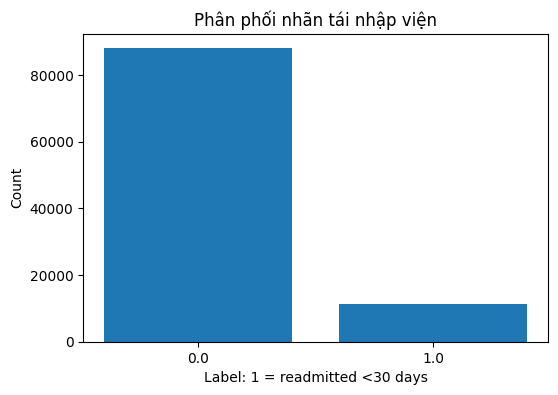

In [33]:
import matplotlib.pyplot as plt

# Biểu đồ phân phối nhãn
label_dist_pd = (
    df.groupBy("label")
    .count()
    .orderBy("label")
    .toPandas()
)

plt.figure(figsize=(6, 4))
plt.bar(label_dist_pd["label"].astype(str), label_dist_pd["count"])
plt.xlabel("Label: 1 = readmitted <30 days")
plt.ylabel("Count")
plt.title("Phân phối nhãn tái nhập viện")
plt.show()

## 14. Feature Importance

Với Random Forest hoặc Gradient-Boosted Tree, có thể lấy `featureImportances`. Do dữ liệu có nhiều biến one-hot, hàm dưới đây trích tên đặc trưng từ metadata của vector `features`.

In [35]:
def get_feature_names_from_metadata(dataframe, features_col="features"):
    metadata = dataframe.schema[features_col].metadata
    attrs = []
    if "ml_attr" in metadata and "attrs" in metadata["ml_attr"]:
        for attr_type in ["numeric", "binary", "nominal"]:
            attrs.extend(metadata["ml_attr"]["attrs"].get(attr_type, []))
        attrs = sorted(attrs, key=lambda x: x["idx"])
        return [a.get("name", f"feature_{a['idx']}") for a in attrs]
    return [f"feature_{i}" for i in range(dataframe.select(features_col).first()[features_col].size)]

feature_names = get_feature_names_from_metadata(train_featurized, "features")
print("Số feature names:", len(feature_names))
print(feature_names[:20])

Số feature names: 2326
['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19']


,feature,importance
6,feature_6,0.086638
1,feature_1,0.041408
0,feature_0,0.037148
3,feature_3,0.036801
8,feature_8,0.035447
5,feature_5,0.028481
2286,feature_2286,0.027144
241,feature_241,0.025903
7,feature_7,0.023969
2292,feature_2292,0.018348


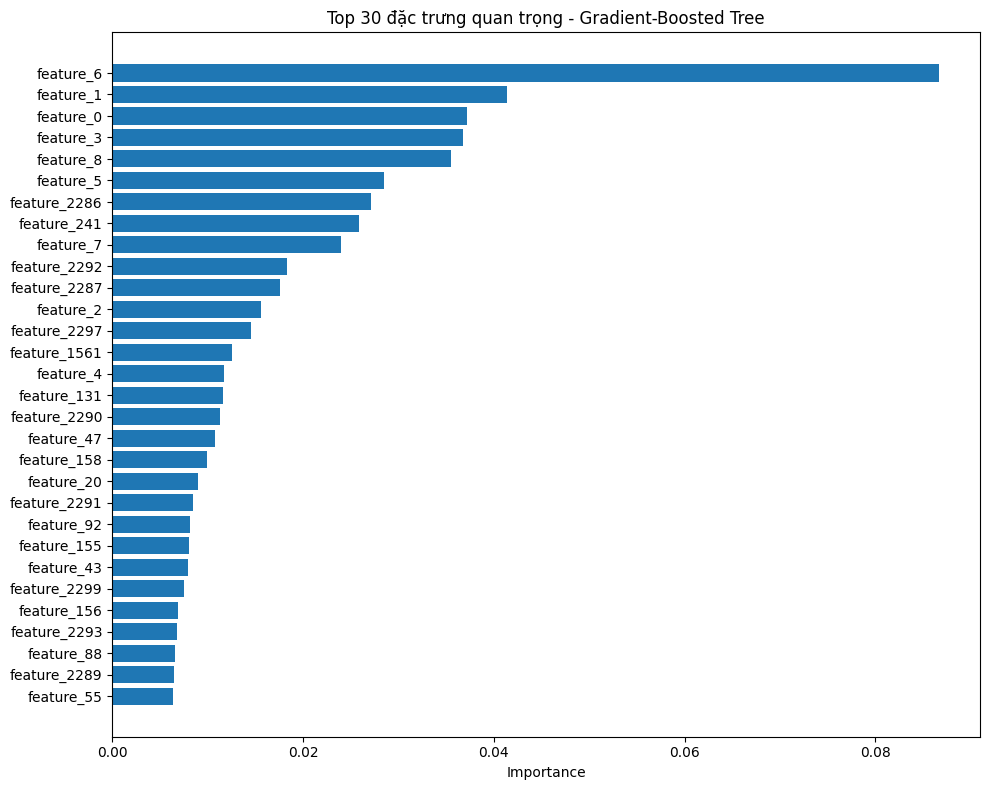

In [36]:
import pandas as pd

if hasattr(best_model, "featureImportances"):
    importances = best_model.featureImportances.toArray()
    feature_importance_pd = (
        pd.DataFrame({
            "feature": feature_names[:len(importances)],
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .head(30)
    )

    display(feature_importance_pd)

    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance_pd["feature"][::-1], feature_importance_pd["importance"][::-1])
    plt.xlabel("Importance")
    plt.title(f"Top 30 đặc trưng quan trọng - {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"Mô hình {best_model_name} không có thuộc tính featureImportances.")

## 15. Tối ưu siêu tham số bằng CrossValidator hoặc TrainValidationSplit

Cell dưới đây là tùy chọn vì có thể tốn thời gian. Với bài báo cáo môn Xử lý dữ liệu lớn, phần này giúp thể hiện khả năng mở rộng của Spark MLlib trong việc tìm tham số tốt hơn.

In [37]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

# Ví dụ tuning cho Random Forest.
# Có thể bỏ qua cell này nếu thời gian chạy quá lâu.

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    seed=42
)

param_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 8])
    .addGrid(rf.featureSubsetStrategy, ["sqrt"])
    .build()
)

tvs = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=param_grid,
    evaluator=auc_evaluator,
    trainRatio=0.8,
    seed=42
)

# Mở comment để chạy tuning:
# rf_tuned_model = tvs.fit(train_featurized)
# tuned_valid_pred = rf_tuned_model.transform(valid_featurized)
# evaluate_binary_predictions(tuned_valid_pred, "Random Forest Tuned", "validation")

## 16. Sinh đầu ra dự đoán nguy cơ cho bệnh nhân

Cột `prob_readmitted_30d` là xác suất dự đoán bệnh nhân tái nhập viện trong vòng 30 ngày.

In [39]:
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

risk_output = (
    test_predictions
    .withColumn(
        "prob_readmitted_30d",
        vector_to_array(F.col("probability"))[1].cast("double")
    )
    .withColumn(
        "risk_level",
        F.when(F.col("prob_readmitted_30d") >= 0.70, F.lit("High"))
         .when(F.col("prob_readmitted_30d") >= 0.40, F.lit("Medium"))
         .otherwise(F.lit("Low"))
    )
    .select(
        "encounter_id",
        "patient_nbr",
        "label",
        "prediction",
        "prob_readmitted_30d",
        "risk_level",
        "time_in_hospital",
        "num_medications",
        "number_inpatient",
        "number_emergency",
        "number_outpatient",
        "number_diagnoses"
    )
)

risk_output.orderBy(F.desc("prob_readmitted_30d")).show(20, truncate=False)

+------------+-----------+-----+----------+-------------------+----------+----------------+---------------+----------------+----------------+-----------------+----------------+
|encounter_id|patient_nbr|label|prediction|prob_readmitted_30d|risk_level|time_in_hospital|num_medications|number_inpatient|number_emergency|number_outpatient|number_diagnoses|
+------------+-----------+-----+----------+-------------------+----------+----------------+---------------+----------------+----------------+-----------------+----------------+
|114379908   |4525299    |1.0  |1.0       |0.9189720608942563 |High      |6.0             |26.0           |6.0             |0.0             |0.0              |9.0             |
|86530626    |23643405   |1.0  |1.0       |0.9049956549401439 |High      |6.0             |11.0           |12.0            |4.0             |1.0              |9.0             |
|397951706   |112504149  |0.0  |1.0       |0.8869447721360187 |High      |8.0             |31.0           |8.0     

In [40]:
risk_output.groupBy("risk_level").count().orderBy(F.desc("count")).show()

+----------+-----+
|risk_level|count|
+----------+-----+
|    Medium| 7751|
|       Low| 6125|
|      High|  900|
+----------+-----+



In [41]:
risk_summary = (
    risk_output
    .groupBy("risk_level")
    .agg(
        F.count("*").alias("num_patients"),
        F.round(F.avg("prob_readmitted_30d"), 4).alias("avg_probability"),
        F.round(F.avg("time_in_hospital"), 2).alias("avg_time_in_hospital"),
        F.round(F.avg("num_medications"), 2).alias("avg_num_medications"),
        F.round(F.avg("number_inpatient"), 2).alias("avg_number_inpatient")
    )
    .orderBy(
        F.when(F.col("risk_level") == "High", 1)
         .when(F.col("risk_level") == "Medium", 2)
         .otherwise(3)
    )
)

risk_summary.show(truncate=False)

+----------+------------+---------------+--------------------+-------------------+--------------------+
|risk_level|num_patients|avg_probability|avg_time_in_hospital|avg_num_medications|avg_number_inpatient|
+----------+------------+---------------+--------------------+-------------------+--------------------+
|High      |900         |0.7583         |5.01                |17.73              |3.62                |
|Medium    |7751        |0.531          |5.12                |17.4               |0.76                |
|Low       |6125        |0.3174         |3.36                |14.04              |0.07                |
+----------+------------+---------------+--------------------+-------------------+--------------------+



In [42]:
risk_summary_pd = risk_summary.toPandas()
display(risk_summary_pd)

,risk_level,num_patients,avg_probability,avg_time_in_hospital,avg_num_medications,avg_number_inpatient
0,High,900,0.7583,5.01,17.73,3.62
1,Medium,7751,0.5310,5.12,17.40,0.76
2,Low,6125,0.3174,3.36,14.04,0.07


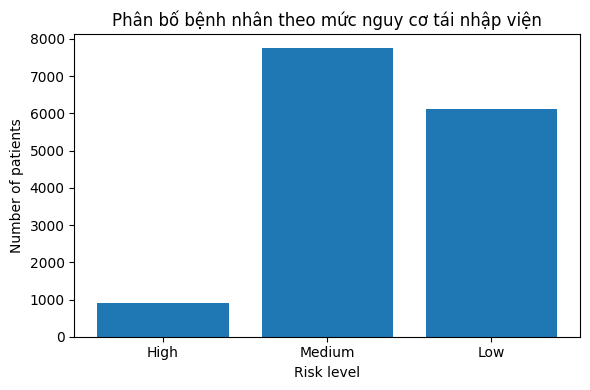

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(risk_summary_pd["risk_level"], risk_summary_pd["num_patients"])
plt.xlabel("Risk level")
plt.ylabel("Number of patients")
plt.title("Phân bố bệnh nhân theo mức nguy cơ tái nhập viện")
plt.tight_layout()
plt.show()

## 17. Lưu pipeline và mô hình

Spark cho phép lưu cả pipeline tiền xử lý và mô hình để tái sử dụng cho dữ liệu mới.

In [ ]:
MODEL_DIR = "spark_models_diabetes_readmission"

preprocess_model.write().overwrite().save(f"{MODEL_DIR}/preprocess_model")
best_model.write().overwrite().save(f"{MODEL_DIR}/best_model_{best_model_name.replace(' ', '_')}")

metrics_df.write.mode("overwrite").option("header", True).csv(f"{MODEL_DIR}/metrics_csv")
risk_output.write.mode("overwrite").parquet(f"{MODEL_DIR}/risk_output_parquet")

print("Đã lưu mô hình và kết quả vào:", MODEL_DIR)